<a href="https://colab.research.google.com/github/viniciuscristall-spec/CP2-SERS/blob/main/CP02_SERS_2SEM_REGRESSAO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Checkpoint 2 – Regressão Linear e Estabilidade da Rede Elétrica

Esta atividade faz parte do **Checkpoint 2**. O objetivo é construir e comparar dois modelos de Regressão Linear para prever o valor numérico da coluna `stab`, relacionada à estabilidade da rede elétrica.

Ao finalizar, salve este notebook no formato `.ipynb` e faça o upload no **repositório GitHub da atividade criado anteriormente**. Mantenha todas as células executadas, os resultados visíveis e as respostas preenchidas.

## 1. Importação das bibliotecas

Importe as bibliotecas necessárias para manipulação e visualização dos dados, separação entre treino e teste, criação do modelo de Regressão Linear e cálculo das métricas R², MAE e MSE.

In [73]:
# Importe aqui as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## 2. Carregamento e análise inicial do dataset

Carregue o arquivo CSV do conjunto **Electrical Grid Stability** em um DataFrame chamado `df`. Depois:

- visualize as primeiras linhas;
- verifique a quantidade de linhas e colunas;
- apresente os nomes e os tipos das colunas;
- verifique se existem valores ausentes;
- apresente as estatísticas descritivas das variáveis numéricas.

In [74]:
# Carregue o dataset e realize a análise inicial
dados = pd.read_csv('https://raw.githubusercontent.com/viniciuscristall-spec/CP2-SERS/refs/heads/main/Data_for_UCI_named.csv')
dados.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


### Registro da análise inicial

**Quantidade de linhas: 10000**  
**Quantidade de colunas: 14**  
**Existem valores ausentes? Não existem**  
**Observações importantes sobre o dataset:**  

In [75]:
dados.shape

(10000, 14)

In [76]:
dados.isnull().sum()

,0
tau1,0
tau2,0
tau3,0
tau4,0
p1,0
p2,0
p3,0
p4,0
g1,0
g2,0


In [77]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


## 3. Definição da variável target

A variável que os modelos deverão prever é a coluna `stab`. Crie a variável `y` com essa coluna e apresente seus primeiros valores.

In [78]:
# Crie a variável y usando a coluna stab
y = dados['stab']
y.head()

,stab
0,0.055347
1,-0.005957
2,0.003471
3,0.028871
4,0.049860


## 4. Matriz de correlação

Calcule a matriz de correlação das variáveis numéricas e crie um mapa de calor (*heatmap*). Em seguida, identifique as **cinco variáveis com maior correlação absoluta com `stab`**, sem considerar a própria coluna `stab`.

Considere também correlações negativas: quanto mais próximo de +1 ou -1, maior é a intensidade da relação linear.

In [79]:
# Calcule e visualize a matriz de correlação
matriz = dados.drop(columns=['stab'])
matriz.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,unstable


## 5. Apoio do Gemini para seleção e visualização das variáveis

Depois de criar a matriz de correlação, use o Gemini no Google Colab com o prompt abaixo. Analise o código sugerido antes de executá-lo e faça os ajustes necessários.

> Tenho um DataFrame Pandas chamado `df` com dados do Electrical Grid Stability. A variável target é a coluna `stab`. Gere um código Python que: (1) calcule a correlação das variáveis numéricas com `stab`; (2) desconsidere a própria coluna `stab`; (3) use o valor absoluto das correlações para identificar as cinco variáveis com maior correlação com `stab`; (4) apresente os nomes das cinco variáveis e os valores originais de correlação, preservando os sinais positivo ou negativo; (5) armazene os nomes dessas variáveis em uma lista chamada `cinco_variaveis`; e (6) crie cinco gráficos de dispersão, um para cada variável selecionada, usando a variável no eixo X e `stab` no eixo Y. Utilize Pandas, Matplotlib e Seaborn. O DataFrame `df` já está carregado.

Cinco variáveis com maior correlação absoluta com a coluna 'stab':
Variável: g3, Correlação: 0.3082
Variável: g2, Correlação: 0.2936
Variável: tau2, Correlação: 0.2910
Variável: g1, Correlação: 0.2828
Variável: tau3, Correlação: 0.2807
Lista das variáveis selecionadas: ['g3', 'g2', 'tau2', 'g1', 'tau3']


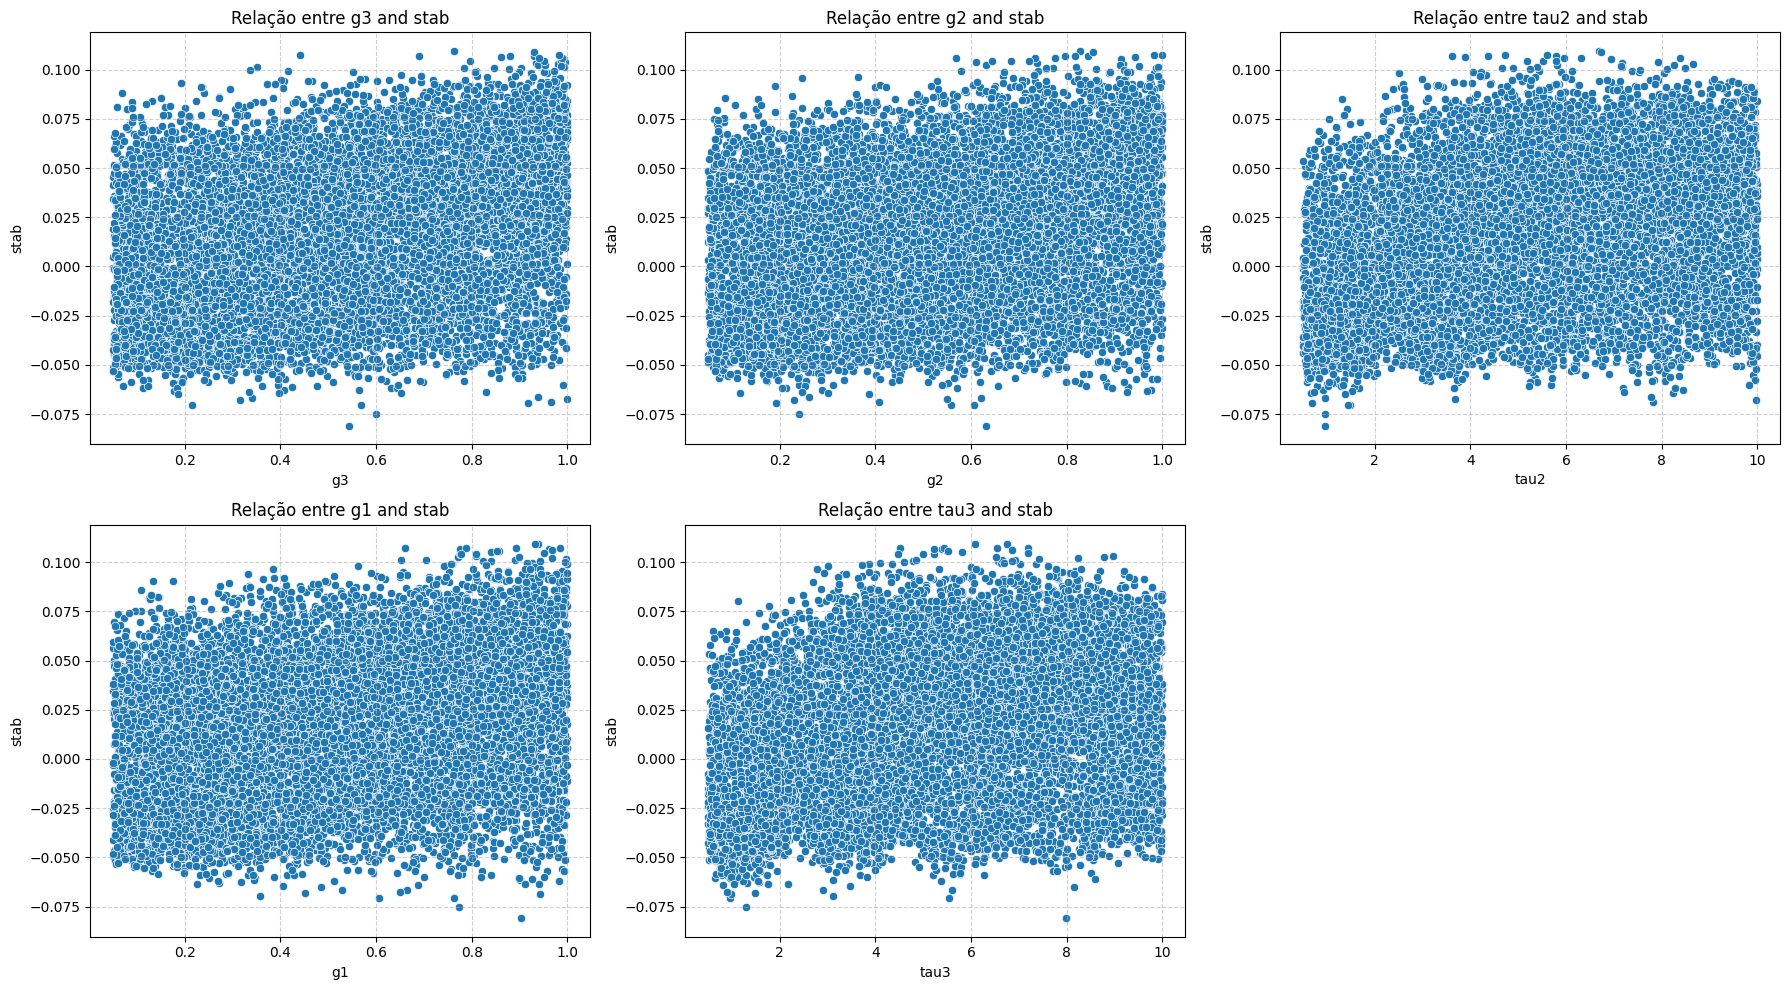

In [80]:
correlations = dados.corr(numeric_only=True)['stab'].sort_values(key=abs, ascending=False)
correlations = correlations.drop('stab')
cinco_variaveis_corr = correlations.head(5)
print("Cinco variáveis com maior correlação absoluta com a coluna 'stab':")
for var, corr_value in cinco_variaveis_corr.items():
    print(f"Variável: {var}, Correlação: {corr_value:.4f}")
cinco_variaveis = cinco_variaveis_corr.index.tolist()
print(f"Lista das variáveis selecionadas: {cinco_variaveis}")

plt.figure(figsize=(18, 10))
for i, var in enumerate(cinco_variaveis):
    plt.subplot(2, 3, i + 1)
    sns.scatterplot(x=dados[var], y=dados['stab'])
    plt.title(f'Relação entre {var} and stab')
    plt.xlabel(var)
    plt.ylabel('stab')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Variáveis selecionadas

| Posição | Variável | Correlação original com `stab` |
|---:|---|---:|
| 1 |  |  |
| 2 |  |  |
| 3 |  |  |
| 4 |  |  |
| 5 |  |  |

**Qual variável apresentou a maior correlação absoluta com `stab`?**  
Resposta:  

**O que os gráficos de dispersão indicam sobre as relações entre essas variáveis e `stab`?**  
Resposta:  

# Modelo 1 – Cinco maiores correlações

Crie o DataFrame `X` utilizando somente as cinco variáveis selecionadas a partir da matriz de correlação. A variável `y` deve continuar sendo a coluna `stab`.

In [81]:
# Crie X com as cinco variáveis selecionadas
# X = ...
X = dados[cinco_variaveis]
# Mostre as primeiras linhas de X e y
X.head()

,g3,g2,tau2,g1,tau3
0,0.887445,0.859578,3.079885,0.650456,8.381025
1,0.562139,0.862414,4.902524,0.413441,3.047541
2,0.839444,0.766689,8.848428,0.163041,3.046479
3,0.929381,0.976744,7.669600,0.446209,4.486641
4,0.656947,0.455450,7.608772,0.797110,4.943759


In [82]:
y.head()

,stab
0,0.055347
1,-0.005957
2,0.003471
3,0.028871
4,0.049860


## 6. Separação entre treino e teste

Separe `X` e `y` utilizando 80% dos dados para treinamento e 20% para teste, com `random_state=42`. Use os nomes `X_treino`, `X_teste`, `y_treino` e `y_teste`. Apresente a quantidade de registros em cada conjunto.

In [83]:
# Separe os dados de treino e teste do Modelo 1
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)
X_treino.shape, X_teste.shape, y_treino.shape, y_teste.shape

((8000, 5), (2000, 5), (8000,), (2000,))

## 7. Treinamento e previsões do Modelo 1

Crie um modelo de Regressão Linear chamado obrigatoriamente `modeloLR`. Treine o modelo e gere as previsões do conjunto de teste em uma variável chamada `y_previsao_1`.

In [84]:
# Crie e treine modeloLR
modeloLR = LinearRegression()
modeloLR.fit(X_treino, y_treino)
# Gere y_previsao_1
y_previsao_1 = modeloLR.predict(X_teste)

## 8. Métricas do Modelo 1

Calcule R², MAE e MSE. Armazene os resultados nas variáveis `r2_modelo_1`, `mae_modelo_1` e `mse_modelo_1`. Esses valores serão usados na comparação final.

In [85]:
# Calcule e apresente as três métricas do Modelo 1
r2_modelo_1 = r2_score(y_teste, y_previsao_1)
mae_modelo_1 = mean_absolute_error(y_teste, y_previsao_1)
mse_modelo_1 = mean_squared_error(y_teste, y_previsao_1)
r2_modelo_1, mae_modelo_1, mse_modelo_1

(0.40176964852172137, 0.023309678710004788, 0.000811420863922188)

# Modelo 2 – Variáveis `tau` e `g`

Crie um novo DataFrame chamado `X_tau_g` contendo todas as colunas cujos nomes começam com `tau` ou `g`. Liste as colunas selecionadas para conferir o resultado. A variável target permanece `y = df['stab']`.

In [86]:
# Selecione todas as colunas iniciadas por tau ou g
# X_tau_g = ...
X_tau_g = dados.filter(regex=r'^(tau|g)')

# Liste as colunas selecionadas
# tau1	tau2	tau3	tau4	g1	g2	g3	g4
X_tau_g.head()

,tau1,tau2,tau3,tau4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,0.797110,0.455450,0.656947,0.820923


## 9. Separação entre treino e teste do Modelo 2

Separe `X_tau_g` e `y` usando novamente 80% para treino, 20% para teste e `random_state=42`. Use os nomes `X2_treino`, `X2_teste`, `y2_treino` e `y2_teste`.

Manter o mesmo `random_state` e a mesma proporção é importante para comparar os modelos sobre os mesmos registros de teste.

In [87]:
# Separe os dados de treino e teste do Modelo 2
X2_treino, X2_teste, y2_treino, y2_teste = train_test_split(X_tau_g, y, test_size=0.2, random_state=42)
# Confirme se y_teste e y2_teste possuem os mesmos índices
y2_teste.shape

(2000,)

y_teste e y2_teste possuem os mesmo índices

## 10. Treinamento, previsões e métricas do Modelo 2

Crie um segundo modelo de Regressão Linear chamado `modeloLR_tau_g`. Treine-o, gere as previsões em `y_previsao_2` e armazene as métricas em `r2_modelo_2`, `mae_modelo_2` e `mse_modelo_2`.

In [88]:
# Crie e treine modeloLR_tau_g
modeloLR_tau_g = LinearRegression()
modeloLR_tau_g.fit(X2_treino, y2_treino)
# Gere y_previsao_2
y_previsao_2 = modeloLR_tau_g.predict(X2_teste)

# Calcule e apresente as três métricas do Modelo 2
r2_modelo_2 = r2_score(y2_teste, y_previsao_2)
mae_modelo_2 = mean_absolute_error(y2_teste, y_previsao_2)
mse_modelo_2 = mean_squared_error(y2_teste, y_previsao_2)
r2_modelo_2, mae_modelo_2, mse_modelo_2

(0.6452288156705858, 0.01755303887582674, 0.00048120049437799794)

# Comparação das métricas dos dois modelos

As métricas devem ser analisadas **comparativamente**. Crie um único DataFrame chamado `comparacao_modelos` com uma linha para cada modelo e as colunas `Modelo`, `Variáveis utilizadas`, `R²`, `MAE` e `MSE`.

Na comparação:

- um **R² maior** indica que o modelo explica uma parcela maior da variação de `stab`;
- um **MAE menor** indica menor erro absoluto médio;
- um **MSE menor** indica menor erro quadrático médio e penaliza mais intensamente os erros maiores.

Não interprete as métricas de forma isolada: compare os valores obtidos pelos dois modelos.

In [89]:
# Crie e exiba o DataFrame comparacao_modelos
comparacao_modelos = pd.DataFrame({
    'Modelo': ['Modelo 1', 'Modelo 2'],
    'Variáveis utilizadas': ['Cinco variáveis', 'Todas as variáveis `tau` e `g`'],
    'R²': [r2_modelo_1, r2_modelo_2],
    'MAE': [mae_modelo_1, mae_modelo_2],
    'MSE': [mse_modelo_1, mse_modelo_2]
})
comparacao_modelos.head()

,Modelo,Variáveis utilizadas,R²,MAE,MSE
0,Modelo 1,Cinco variáveis,0.401770,0.023310,0.000811
1,Modelo 2,Todas as variáveis `tau` e `g`,0.645229,0.017553,0.000481


## Visualização comparativa

Crie três gráficos de barras lado a lado ou em uma mesma figura:

1. R² dos dois modelos;
2. MAE dos dois modelos;
3. MSE dos dois modelos.

Identifique os modelos e as métricas com títulos e rótulos claros.

/tmp/ipykernel_6311/3371284686.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='R²', data=comparacao_modelos, ax=axes[0], palette='viridis')
/tmp/ipykernel_6311/3371284686.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='MAE', data=comparacao_modelos, ax=axes[1], palette='plasma')
/tmp/ipykernel_6311/3371284686.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='MSE', data=comparacao_modelos, ax=axes[2], palette='magma')


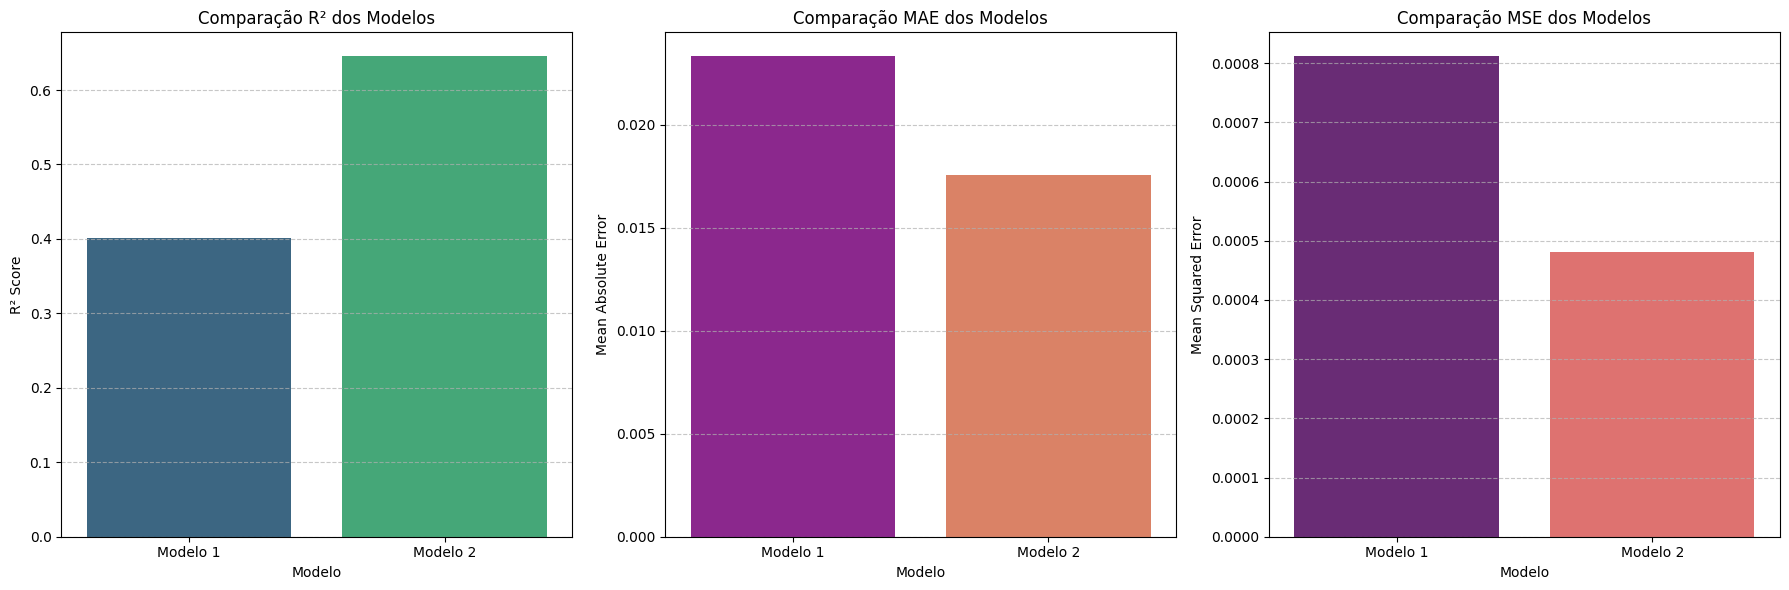

In [90]:
# Crie os gráficos comparativos das métricas

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(x='Modelo', y='R²', data=comparacao_modelos, ax=axes[0], palette='viridis')
axes[0].set_title('Comparação R² dos Modelos')
axes[0].set_ylabel('R² Score')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.barplot(x='Modelo', y='MAE', data=comparacao_modelos, ax=axes[1], palette='plasma')
axes[1].set_title('Comparação MAE dos Modelos')
axes[1].set_ylabel('Mean Absolute Error')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

sns.barplot(x='Modelo', y='MSE', data=comparacao_modelos, ax=axes[2], palette='magma')
axes[2].set_title('Comparação MSE dos Modelos')
axes[2].set_ylabel('Mean Squared Error')
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Análise comparativa final

Responda com base na tabela e nos gráficos comparativos.

**1. Qual modelo apresentou o maior R²? Informe os valores dos dois modelos.**  
Resposta: O modelo1 apensentou o valor 0.401770, enquanto o modelo2 apresentou 0.645229, portanto o modelo2 apresentou um maior R²

**2. Qual modelo apresentou o menor MAE? Informe os valores dos dois modelos.**  
Resposta: O modelo1 apensentou o valor 0.023310, enquanto o modelo2 apresentou 0.017553, portanto o modelo2 apresentou o menor MAE

**3. Qual modelo apresentou o menor MSE? Informe os valores dos dois modelos.**  
Resposta: O modelo1 apensentou o valor 0.000811, enquanto o modelo2 apresentou 0.000481, portanto o modelo2 apresentou o menor MSE

**4. As três métricas indicaram o mesmo modelo como o de melhor desempenho? Justifique comparando os resultados.**  
Resposta: Sim, as três métricas indicaram o Modelo 2 como o de melhor desempenho. O Modelo 2 apresentou um R² maior (0.645229 vs 0.401770), um MAE menor (0.017553 vs 0.023310) e um MSE menor (0.000481 vs 0.000811) em comparação com o Modelo 1. Em todas as métricas, os valores do Modelo 2 são superiores (R²) ou inferiores (MAE, MSE), indicando consistentemente um desempenho superior.

**5. O que mudou no desempenho quando as cinco variáveis de maior correlação foram substituídas pelo conjunto completo de variáveis `tau` e `g`?**  
Resposta: Houve uma melhora significativa em todas as métricas de desempenho. O R² aumentou de 0.401770 para 0.645229, o que significa que o Modelo 2 explica uma proporção muito maior da variância da variável `stab`. Consequentemente, o MAE e o MSE diminuíram, indicando que o Modelo 2 possui erros médios absolutos e quadráticos menores, ou seja, suas previsões são mais precisas e com menor penalidade para erros maiores.

**6. Considerando os resultados obtidos, qual modelo você escolheria para prever `stab`? Justifique com R², MAE e MSE.**  
Resposta: Eu escolheria o Modelo 2 para prever `stab`. Minha justificativa é baseada nas métricas: o Modelo 2 tem um R² de 0.645229, o que é substancialmente maior que o 0.401770 do Modelo 1, indicando que ele captura melhor a variabilidade dos dados. Além disso, o Modelo 2 apresenta um MAE de 0.017553 e um MSE de 0.000481, ambos menores que os valores do Modelo 1 (0.023310 e 0.000811, respectivamente). Isso demonstra que o Modelo 2 tem uma menor média de erros absolutos e quadráticos, resultando em previsões mais próximas dos valores reais de `stab`.

# Conferência e entrega

Antes de entregar, verifique se o notebook contém:

- identificação dos integrantes;
- carregamento e análise inicial do dataset;
- `y` definido com a coluna `stab`;
- matriz de correlação e mapa de calor;
- seleção das cinco maiores correlações absolutas;
- cinco gráficos de dispersão em relação a `stab`;
- Modelo 1 com as cinco variáveis selecionadas;
- Modelo 2 com todas as variáveis `tau` e `g`;
- R², MAE e MSE dos dois modelos;
- tabela e gráficos comparativos das métricas;
- respostas da análise comparativa final;
- todas as células executadas e sem erros.

Salve o arquivo `.ipynb` e faça o upload no **repositório GitHub da atividade criado anteriormente**. Este notebook fará parte do **Checkpoint 2**.